In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


In [2]:
RESULTS_DIR = Path(r"C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results")
OUTPUT_DIR = RESULTS_DIR / "visualizations"
OUTPUT_DIR.mkdir(exist_ok=True)

FILENAME_PATTERN = re.compile(
    r"^(.+?)__lrh-([\d.eE\-]+)__lrf-([\d.eE\-]+)__wd-([\d.eE\-]+)__ran-.+\.csv$",
    re.IGNORECASE
)

print("RESULTS_DIR:", RESULTS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())


RESULTS_DIR: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results
OUTPUT_DIR: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations
RESULTS_DIR exists: True


In [3]:
def parse_filename(filepath: Path):
    match = FILENAME_PATTERN.match(filepath.name)
    if not match:
        return None
    
    return {
        "model_from_filename": match.group(1),
        "lrh": match.group(2),
        "lrf": match.group(3),
        "wd": match.group(4),
    }


In [4]:
def load_all_results(results_dir: Path) -> pd.DataFrame:
    records = []
    discovered_csvs = 0
    matched_csvs = 0
    skipped_filenames = []

    for folder in results_dir.iterdir():
        if not folder.is_dir():
            continue
        if folder.name.startswith(".") or folder.name == "visualizations":
            continue

        for csv_path in folder.glob("*.csv"):
            discovered_csvs += 1

            if csv_path.name.startswith(".~lock"):
                continue

            params = parse_filename(csv_path)
            if params is None:
                skipped_filenames.append(csv_path.name)
                continue

            matched_csvs += 1

            try:
                df_one = pd.read_csv(csv_path)
            except Exception as e:
                print(f"Warning: could not read {csv_path}: {e}")
                continue

            df_one["folder_model"] = folder.name
            df_one["lrh"] = params["lrh"]
            df_one["lrf"] = params["lrf"]
            df_one["wd"] = params["wd"]
            df_one["config_id"] = f"{params['lrh']}_{params['lrf']}_{params['wd']}"
            df_one["source_file"] = csv_path.name

            records.append(df_one)

    print("Discovered CSVs:", discovered_csvs)
    print("Matched filename pattern:", matched_csvs)
    if skipped_filenames:
        print("Skipped filename examples:", skipped_filenames[:5])

    if not records:
        raise FileNotFoundError(f"No valid CSV files found in {results_dir}")

    df = pd.concat(records, ignore_index=True)

    required_cols = ["split", "group_type", "epoch", "auc", "group_name"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    return df

df = load_all_results(RESULTS_DIR)
print("Loaded shape:", df.shape)


Discovered CSVs: 48
Matched filename pattern: 48
Loaded shape: (12672, 14)


In [5]:
print("Models:", sorted(df["folder_model"].dropna().unique().tolist()))
print("Splits:", sorted(df["split"].dropna().unique().tolist()))
print("Group types:", sorted(df["group_type"].dropna().unique().tolist()))
print("Epoch range:", df["epoch"].min(), "to", df["epoch"].max())

display(df.head())


Models: ['convnext_t', 'deit_small', 'efficientnet_b4', 'resnet34', 'swin_tiny', 'vgg19_hf']
Splits: ['test', 'val']
Group types: ['age_bin', 'gender', 'label']
Epoch range: 0 to 10


,epoch,split,group_type,group_name,auc,model_name,seed,run_id,folder_model,lrh,lrf,wd,config_id,source_file
0,0,val,label,No Finding,0.803839,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
1,0,val,label,Enlarged Cardiomediastinum,0.565262,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
2,0,val,label,Cardiomegaly,0.698092,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
3,0,val,label,Lung Opacity,0.672835,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
4,0,val,label,Lung Lesion,0.672570,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...


In [6]:
display(
    df.groupby(["split", "group_type"])
      .size()
      .reset_index(name="n_rows")
      .sort_values(["split", "group_type"])
)


,split,group_type,n_rows
0,test,age_bin,384
1,test,gender,96
2,test,label,672
3,val,age_bin,3840
4,val,gender,960
5,val,label,6720


In [7]:
val_label_auc = (
    df[(df["split"] == "val") & (df["group_type"] == "label")]
    .groupby(["folder_model", "config_id", "epoch"], as_index=False)["auc"]
    .mean()
    .rename(columns={"auc": "mean_val_label_auc"})
)

display(val_label_auc.head())
print("val_label_auc shape:", val_label_auc.shape)


,folder_model,config_id,epoch,mean_val_label_auc
0,convnext_t,1e-4_1e-5_1e-2,0,0.693602
1,convnext_t,1e-4_1e-5_1e-2,1,0.707406
2,convnext_t,1e-4_1e-5_1e-2,2,0.712819
3,convnext_t,1e-4_1e-5_1e-2,3,0.766888
4,convnext_t,1e-4_1e-5_1e-2,4,0.777013


val_label_auc shape: (480, 4)


In [8]:
idx_best_epoch_per_config = val_label_auc.groupby(["folder_model", "config_id"])["mean_val_label_auc"].idxmax()

best_epoch_per_config = (
    val_label_auc.loc[idx_best_epoch_per_config]
    .reset_index(drop=True)
    .sort_values(["folder_model", "config_id"])
)

display(best_epoch_per_config.head(10))
print("best_epoch_per_config shape:", best_epoch_per_config.shape)


,folder_model,config_id,epoch,mean_val_label_auc
0,convnext_t,1e-4_1e-5_1e-2,8,0.791219
1,convnext_t,1e-4_1e-5_1e-3,8,0.791152
2,convnext_t,1e-4_3e-5_1e-2,5,0.794910
3,convnext_t,1e-4_3e-5_1e-3,5,0.794912
4,convnext_t,3e-4_1e-5_1e-2,8,0.790969
5,convnext_t,3e-4_1e-5_1e-3,8,0.790883
6,convnext_t,3e-4_3e-5_1e-2,6,0.795294
7,convnext_t,3e-4_3e-5_1e-3,6,0.795187
8,deit_small,1e-4_1e-5_1e-2,8,0.788699
9,deit_small,1e-4_1e-5_1e-3,8,0.788605


best_epoch_per_config shape: (48, 4)


In [9]:
idx_best_config_per_model = best_epoch_per_config.groupby("folder_model")["mean_val_label_auc"].idxmax()

best_config_per_model = (
    best_epoch_per_config.loc[idx_best_config_per_model]
    .reset_index(drop=True)
    .sort_values("folder_model")
)

display(best_config_per_model)


,folder_model,config_id,epoch,mean_val_label_auc
0,convnext_t,3e-4_3e-5_1e-2,6,0.795294
1,deit_small,1e-4_3e-5_1e-2,7,0.792467
2,efficientnet_b4,1e-4_3e-5_1e-2,6,0.787726
3,resnet34,3e-4_3e-5_1e-3,7,0.789425
4,swin_tiny,1e-4_3e-5_1e-3,8,0.792398
5,vgg19_hf,1e-4_3e-5_1e-2,8,0.787047


In [10]:
def build_final_test_rows_for_best_configs(df: pd.DataFrame, best_config_df: pd.DataFrame) -> pd.DataFrame:
    test_df = df[df["split"] == "test"].copy()

    keys = best_config_df[["folder_model", "config_id"]].drop_duplicates()

    merged = test_df.merge(
        keys,
        on=["folder_model", "config_id"],
        how="inner"
    )

    if merged.empty:
        return merged

    final_epochs = (
        merged.groupby(["folder_model", "config_id"], as_index=False)["epoch"]
        .max()
        .rename(columns={"epoch": "final_test_epoch"})
    )

    merged = merged.merge(
        final_epochs,
        on=["folder_model", "config_id"],
        how="left"
    )

    merged = merged[merged["epoch"] == merged["final_test_epoch"]].copy()
    merged.drop(columns=["final_test_epoch"], inplace=True)

    return merged

test_best = build_final_test_rows_for_best_configs(df, best_config_per_model)

print("test_best shape:", test_best.shape)
display(test_best.head())


test_best shape: (144, 14)


,epoch,split,group_type,group_name,auc,model_name,seed,run_id,folder_model,lrh,lrf,wd,config_id,source_file
0,10,test,label,No Finding,0.867020,convnext_t,42,20260308_082500_lrh3e-4_lrf3e-5_wd1e-2_seed42,convnext_t,3e-4,3e-5,1e-2,3e-4_3e-5_1e-2,convnext_t__lrh-3e-4__lrf-3e-5__wd-1e-2__ran-2...
1,10,test,label,Enlarged Cardiomediastinum,0.662311,convnext_t,42,20260308_082500_lrh3e-4_lrf3e-5_wd1e-2_seed42,convnext_t,3e-4,3e-5,1e-2,3e-4_3e-5_1e-2,convnext_t__lrh-3e-4__lrf-3e-5__wd-1e-2__ran-2...
2,10,test,label,Cardiomegaly,0.847641,convnext_t,42,20260308_082500_lrh3e-4_lrf3e-5_wd1e-2_seed42,convnext_t,3e-4,3e-5,1e-2,3e-4_3e-5_1e-2,convnext_t__lrh-3e-4__lrf-3e-5__wd-1e-2__ran-2...
3,10,test,label,Lung Opacity,0.721909,convnext_t,42,20260308_082500_lrh3e-4_lrf3e-5_wd1e-2_seed42,convnext_t,3e-4,3e-5,1e-2,3e-4_3e-5_1e-2,convnext_t__lrh-3e-4__lrf-3e-5__wd-1e-2__ran-2...
4,10,test,label,Lung Lesion,0.769204,convnext_t,42,20260308_082500_lrh3e-4_lrf3e-5_wd1e-2_seed42,convnext_t,3e-4,3e-5,1e-2,3e-4_3e-5_1e-2,convnext_t__lrh-3e-4__lrf-3e-5__wd-1e-2__ran-2...


In [21]:
print("Best config per model:")
display(best_config_per_model)

print("\nCounts in test_best by group_type:")
display(test_best["group_type"].value_counts(dropna=False))

print("\nCounts in test_best by model/config/epoch:")
display(
    test_best.groupby(["folder_model", "config_id", "epoch"])
    .size()
    .reset_index(name="n_rows")
    .sort_values(["folder_model", "config_id", "epoch"])
)



Best config per model:


,folder_model,config_id,epoch,mean_val_label_auc
0,convnext_t,3e-4_3e-5_1e-2,6,0.795294
1,deit_small,1e-4_3e-5_1e-2,7,0.792467
2,efficientnet_b4,1e-4_3e-5_1e-2,6,0.787726
3,resnet34,3e-4_3e-5_1e-3,7,0.789425
4,swin_tiny,1e-4_3e-5_1e-3,8,0.792398
5,vgg19_hf,1e-4_3e-5_1e-2,8,0.787047



Counts in test_best by group_type:


group_type
label      84
age_bin    48
gender     12
Name: count, dtype: int64


Counts in test_best by model/config/epoch:


,folder_model,config_id,epoch,n_rows
0,convnext_t,3e-4_3e-5_1e-2,10,24
1,deit_small,1e-4_3e-5_1e-2,10,24
2,efficientnet_b4,1e-4_3e-5_1e-2,10,24
3,resnet34,3e-4_3e-5_1e-3,10,24
4,swin_tiny,1e-4_3e-5_1e-3,10,24
5,vgg19_hf,1e-4_3e-5_1e-2,10,24


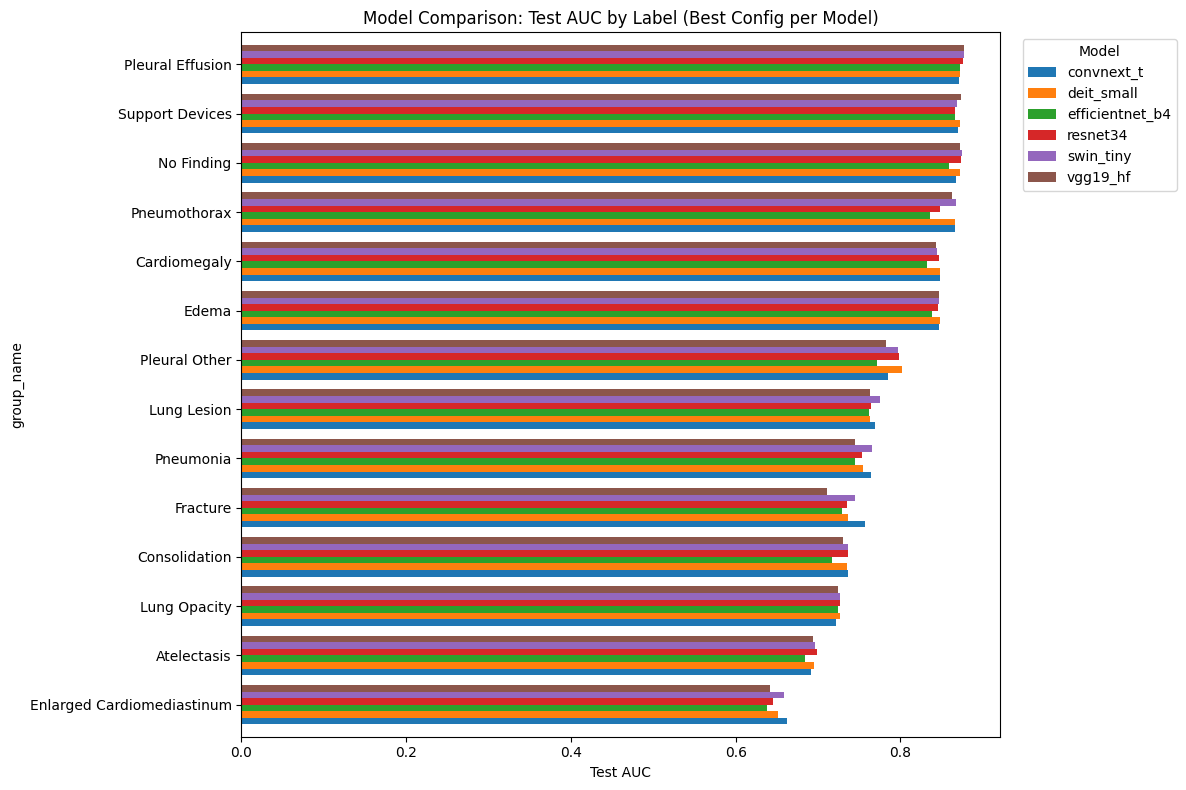

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\model_comparison_by_label.png


In [22]:
def plot_model_comparison_by_label(test_best_df: pd.DataFrame, output_dir: Path):
    plot_df = test_best_df[test_best_df["group_type"] == "label"].copy()

    if plot_df.empty:
        print("Skipping model comparison by label: no test label rows for best configs.")
        return

    pivot = plot_df.pivot_table(
        index="group_name",
        columns="folder_model",
        values="auc",
        aggfunc="mean"
    )

    if pivot.empty:
        print("Skipping model comparison by label: pivot is empty.")
        return

    first_col = pivot.columns[0]
    pivot = pivot.sort_values(by=first_col, ascending=True)

    ax = pivot.plot(kind="barh", width=0.8, figsize=(12, 8))
    ax.set_xlabel("Test AUC")
    ax.set_title("Model Comparison: Test AUC by Label (Best Config per Model)")
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    out = output_dir / "model_comparison_by_label.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out)

plot_model_comparison_by_label(test_best, OUTPUT_DIR)


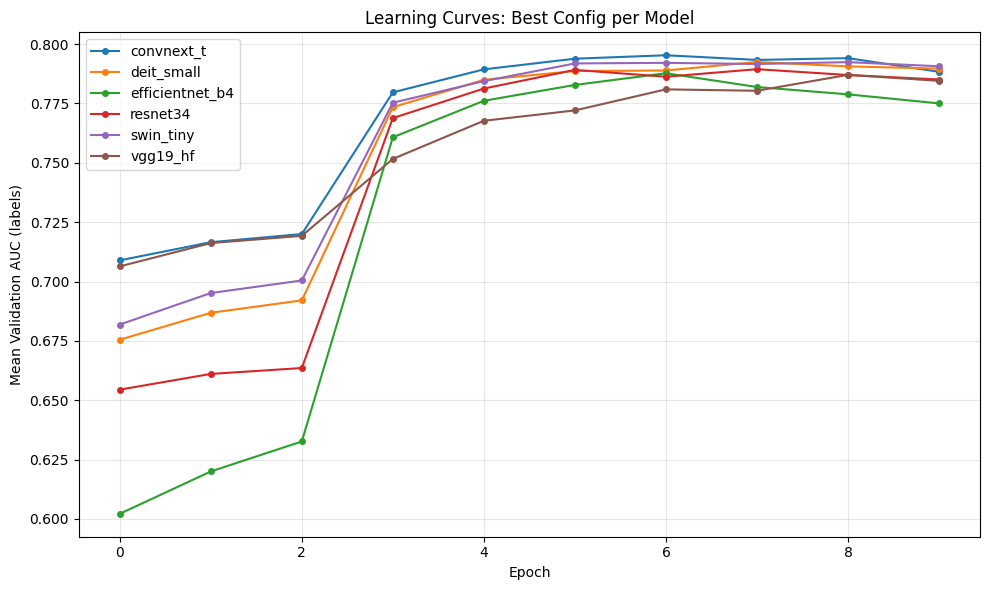

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\learning_curves.png


In [23]:
def plot_learning_curves(df: pd.DataFrame, best_config_df: pd.DataFrame, output_dir: Path):
    val_labels = df[(df["split"] == "val") & (df["group_type"] == "label")].copy()

    keys = best_config_df[["folder_model", "config_id"]].drop_duplicates()

    plot_data = val_labels.merge(
        keys,
        on=["folder_model", "config_id"],
        how="inner"
    )

    if plot_data.empty:
        print("Skipping learning curves: merged plot data is empty.")
        return

    mean_curve = (
        plot_data.groupby(["folder_model", "epoch"], as_index=False)["auc"]
        .mean()
    )

    plt.figure(figsize=(10, 6))
    for model in sorted(mean_curve["folder_model"].unique()):
        sub = mean_curve[mean_curve["folder_model"] == model].sort_values("epoch")
        plt.plot(sub["epoch"], sub["auc"], marker="o", markersize=4, label=model)

    plt.xlabel("Epoch")
    plt.ylabel("Mean Validation AUC (labels)")
    plt.title("Learning Curves: Best Config per Model")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out = output_dir / "learning_curves.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out)

plot_learning_curves(df, best_config_per_model, OUTPUT_DIR)


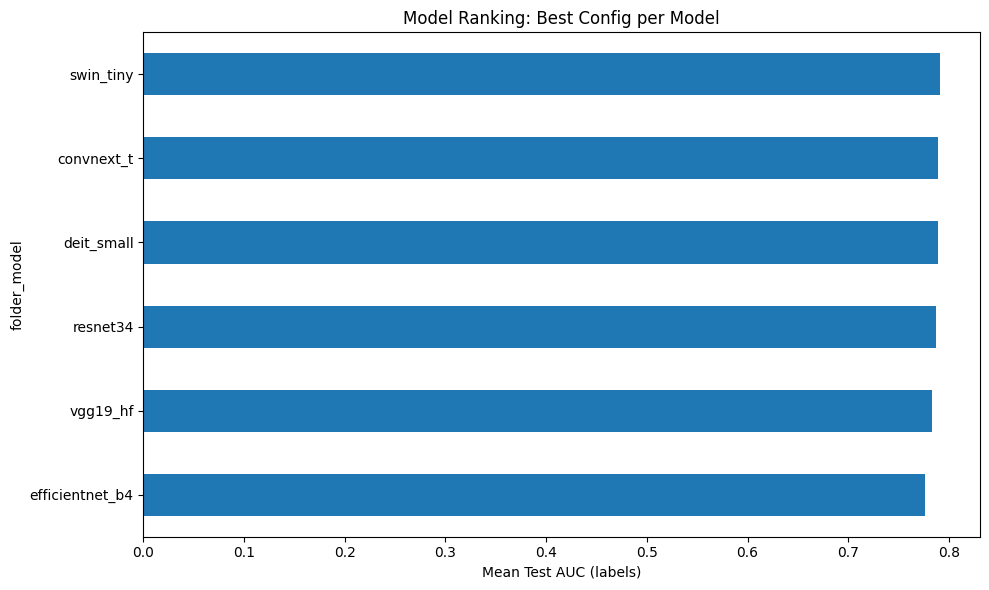

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\model_ranking.png


In [24]:
def plot_overall_ranking(test_best_df: pd.DataFrame, output_dir: Path):
    plot_df = test_best_df[test_best_df["group_type"] == "label"].copy()

    if plot_df.empty:
        print("Skipping overall ranking: no test label rows.")
        return

    ranking = (
        plot_df.groupby("folder_model")["auc"]
        .mean()
        .sort_values(ascending=True)
    )

    if ranking.empty:
        print("Skipping overall ranking: ranking is empty.")
        return

    ax = ranking.plot(kind="barh", figsize=(10, 6))
    ax.set_xlabel("Mean Test AUC (labels)")
    ax.set_title("Model Ranking: Best Config per Model")
    plt.tight_layout()

    out = output_dir / "model_ranking.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out)

plot_overall_ranking(test_best, OUTPUT_DIR)


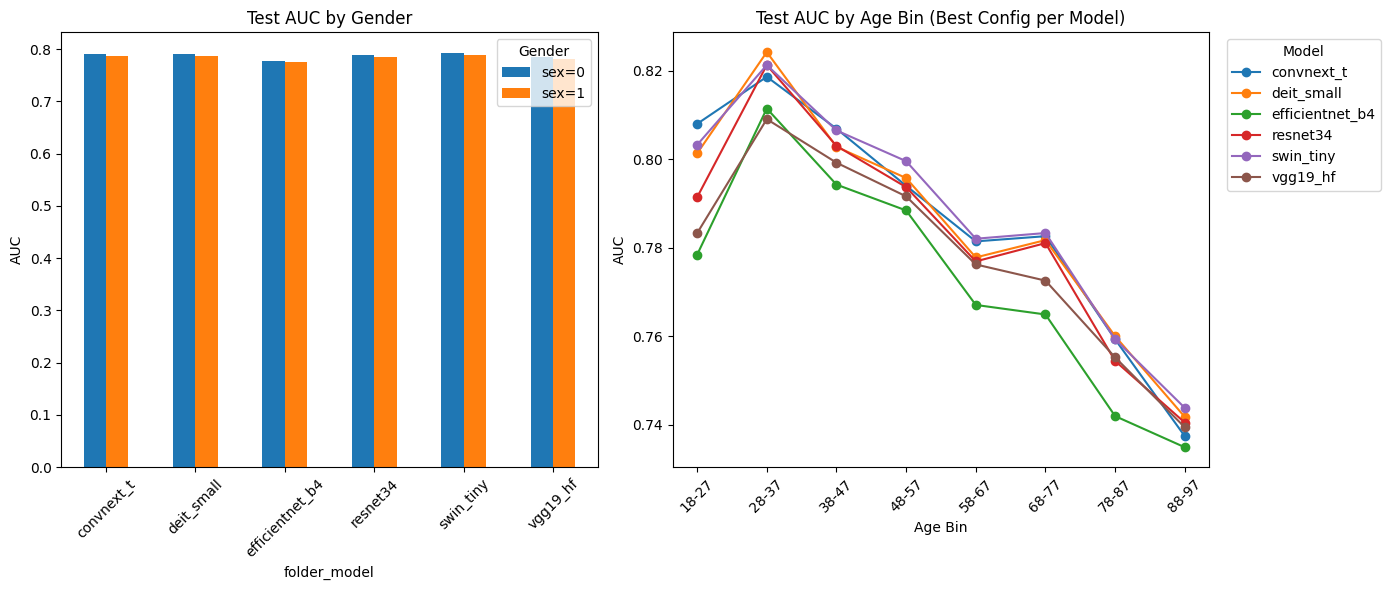

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\fairness_comparison.png


In [25]:
def plot_fairness_comparison(test_best_df: pd.DataFrame, output_dir: Path):
    fairness_df = test_best_df[test_best_df["group_type"].isin(["gender", "age_bin"])].copy()

    if fairness_df.empty:
        print("Skipping fairness comparison: no gender/age_bin rows.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    gender_data = fairness_df[fairness_df["group_type"] == "gender"]
    pivot_g = gender_data.pivot_table(
        index="folder_model",
        columns="group_name",
        values="auc",
        aggfunc="mean"
    )

    if not pivot_g.empty:
        pivot_g.plot(kind="bar", ax=axes[0], rot=45)
        axes[0].set_title("Test AUC by Gender")
        axes[0].set_ylabel("AUC")
        axes[0].legend(title="Gender")
    else:
        axes[0].text(0.5, 0.5, "No gender data", ha="center", va="center")
        axes[0].set_axis_off()

    age_data = fairness_df[fairness_df["group_type"] == "age_bin"]
    pivot_a = age_data.pivot_table(
        index="group_name",
        columns="folder_model",
        values="auc",
        aggfunc="mean"
    )

    if not pivot_a.empty:
        pivot_a.plot(ax=axes[1], marker="o")
        axes[1].set_title("Test AUC by Age Bin (Best Config per Model)")
        axes[1].set_xlabel("Age Bin")
        axes[1].set_ylabel("AUC")
        axes[1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].text(0.5, 0.5, "No age-bin data", ha="center", va="center")
        axes[1].set_axis_off()

    plt.tight_layout()

    out = output_dir / "fairness_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out)

plot_fairness_comparison(test_best, OUTPUT_DIR)


In [26]:
def build_final_test_rows_per_config(df: pd.DataFrame) -> pd.DataFrame:
    test_df = df[(df["split"] == "test") & (df["group_type"] == "label")].copy()

    if test_df.empty:
        return test_df

    final_epochs = (
        test_df.groupby(["folder_model", "config_id"], as_index=False)["epoch"]
        .max()
        .rename(columns={"epoch": "final_test_epoch"})
    )

    merged = test_df.merge(
        final_epochs,
        on=["folder_model", "config_id"],
        how="left"
    )

    merged = merged[merged["epoch"] == merged["final_test_epoch"]].copy()
    merged.drop(columns=["final_test_epoch"], inplace=True)

    return merged

test_rows_final_per_config = build_final_test_rows_per_config(df)

print("test_rows_final_per_config shape:", test_rows_final_per_config.shape)
display(test_rows_final_per_config.head())


test_rows_final_per_config shape: (672, 14)


,epoch,split,group_type,group_name,auc,model_name,seed,run_id,folder_model,lrh,lrf,wd,config_id,source_file
0,10,test,label,No Finding,0.874424,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
1,10,test,label,Enlarged Cardiomediastinum,0.655691,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
2,10,test,label,Cardiomegaly,0.848167,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
3,10,test,label,Lung Opacity,0.727789,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...
4,10,test,label,Lung Lesion,0.775310,convnext_t,42,20260308_202108_lrh1e-4_lrf1e-5_wd1e-2_seed42,convnext_t,1e-4,1e-5,1e-2,1e-4_1e-5_1e-2,convnext_t__lrh-1e-4__lrf-1e-5__wd-1e-2__ran-2...


In [27]:
def plot_hyperparameter_heatmap(test_rows_df: pd.DataFrame, model_name: str, output_dir: Path):
    model_df = test_rows_df[test_rows_df["folder_model"] == model_name].copy()

    if model_df.empty:
        print(f"Skipping heatmap for {model_name}: no rows.")
        return

    mean_auc = (
        model_df.groupby(["lrh", "lrf", "wd"], as_index=False)["auc"]
        .mean()
    )

    if mean_auc.empty:
        print(f"Skipping heatmap for {model_name}: grouped mean_auc empty.")
        return

    pivot = mean_auc.pivot_table(
        index="lrf",
        columns="lrh",
        values="auc",
        aggfunc="mean"
    )

    if pivot.empty:
        print(f"Skipping heatmap for {model_name}: pivot empty.")
        return

    plt.figure(figsize=(8, 6))
    plt.imshow(pivot.values, aspect="auto", vmin=0.5, vmax=0.9)
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [str(y) for y in pivot.index])
    plt.xlabel("Learning Rate Head (lrh)")
    plt.ylabel("Learning Rate Final (lrf)")
    plt.title(f"Test AUC by Hyperparameters: {model_name}")
    plt.colorbar(label="Mean Test AUC")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            text = f"{val:.3f}" if pd.notna(val) else "N/A"
            plt.text(j, i, text, ha="center", va="center", fontsize=9)

    plt.tight_layout()

    safe_name = model_name.replace(" ", "_")
    out = output_dir / f"heatmap_{safe_name}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out)


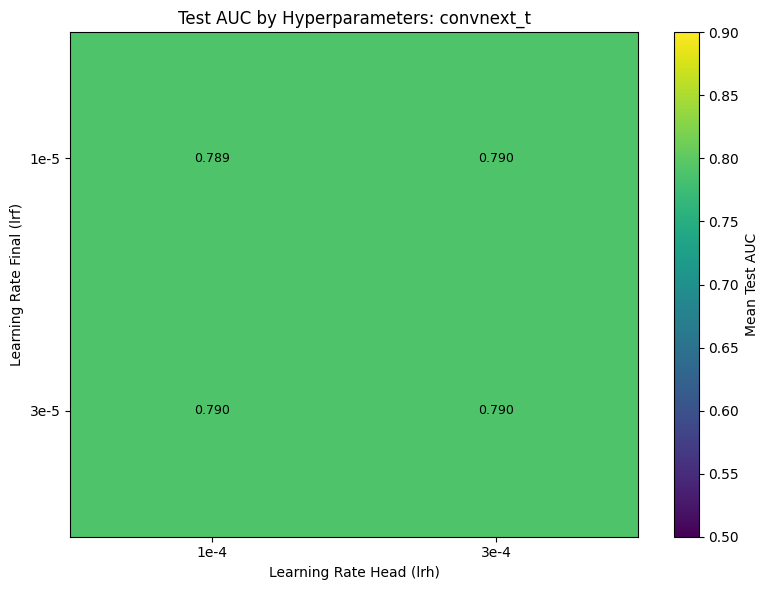

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\heatmap_convnext_t.png


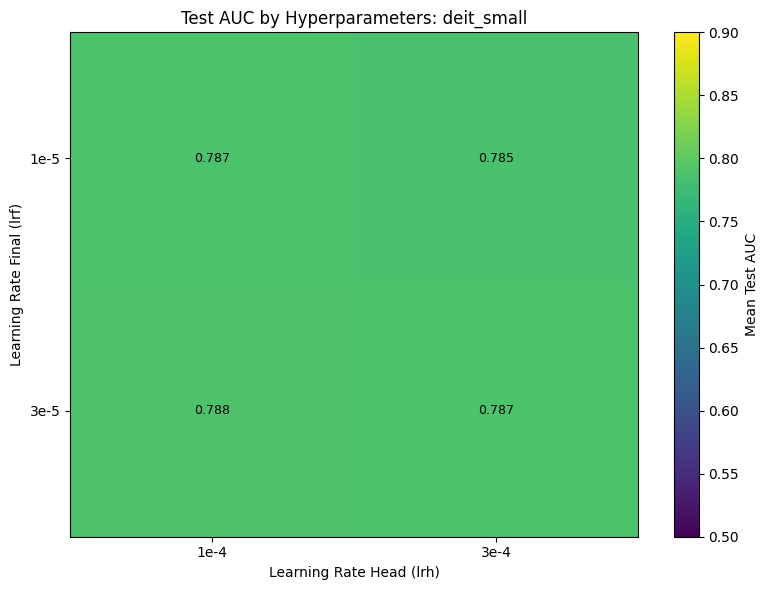

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\heatmap_deit_small.png


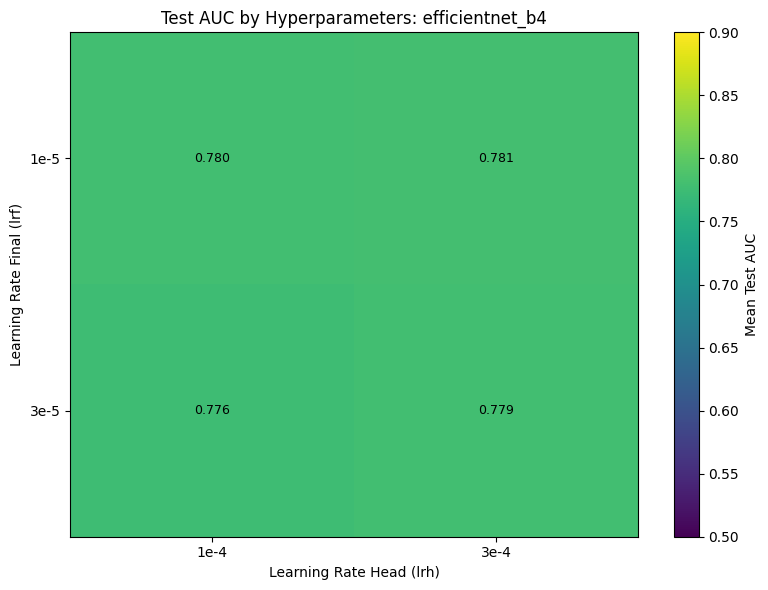

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\heatmap_efficientnet_b4.png


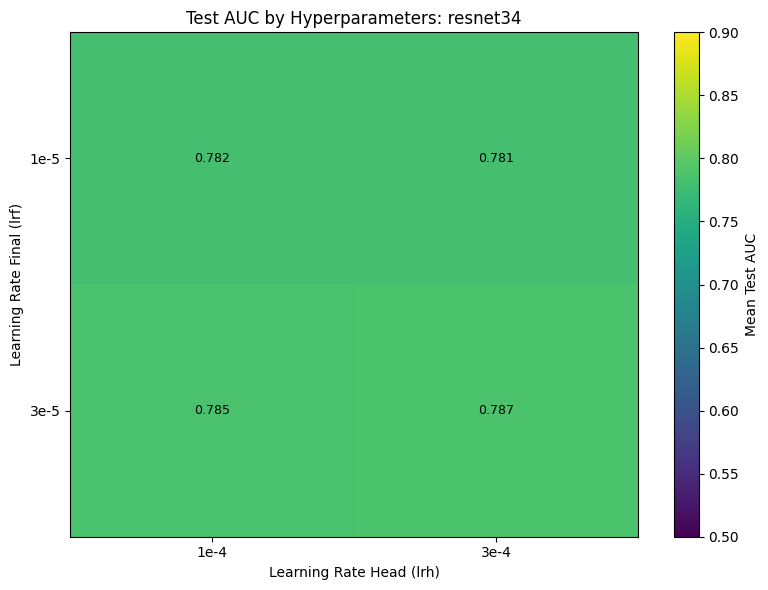

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\heatmap_resnet34.png


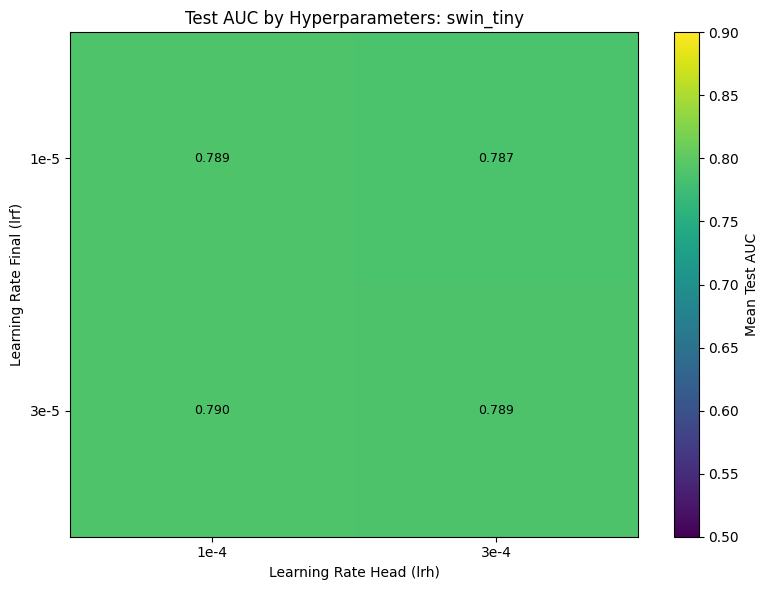

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\heatmap_swin_tiny.png


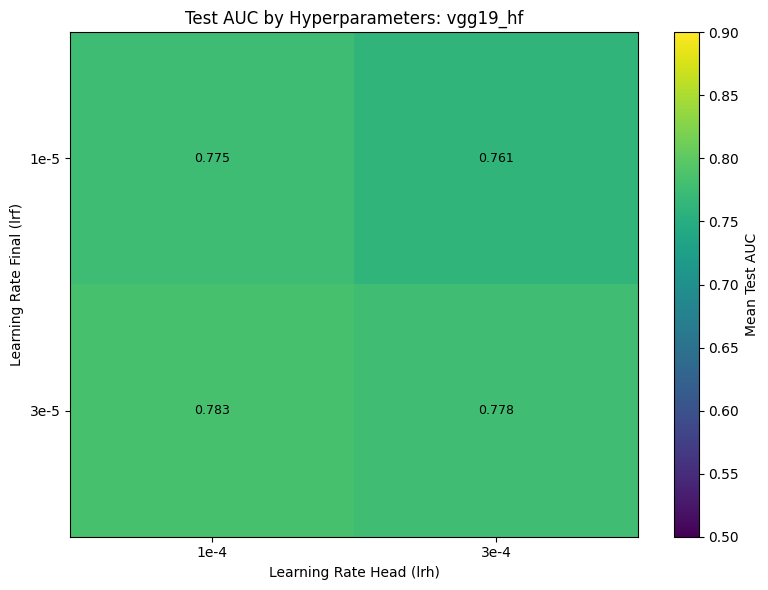

Saved: C:\Users\Ray\Desktop\downloads\all_model_results\all_model_results\visualizations\heatmap_vgg19_hf.png


In [28]:
for model in sorted(df["folder_model"].dropna().unique()):
    plot_hyperparameter_heatmap(test_rows_final_per_config, model, OUTPUT_DIR)


In [29]:
def print_summary_report(df: pd.DataFrame, best_config_df: pd.DataFrame, test_best_df: pd.DataFrame):
    test_labels = test_best_df[test_best_df["group_type"] == "label"].copy()

    print("\n" + "=" * 70)
    print("MODEL COMPARISON REPORT")
    print("=" * 70)

    if test_labels.empty:
        print("No test label rows found for best configs.")
        return

    overall = (
        test_labels.groupby("folder_model")["auc"]
        .agg(["mean", "std", "min", "max"])
        .round(4)
        .sort_values("mean", ascending=False)
    )

    print("\n--- Overall Mean Test AUC (labels, best config per model) ---")
    print(overall.to_string())

    print("\n--- Best Hyperparameter Config per Model ---")
    for _, row in best_config_df.sort_values("folder_model").iterrows():
        model = row["folder_model"]
        config_id = row["config_id"]

        cfg_rows = test_labels[
            (test_labels["folder_model"] == model) &
            (test_labels["config_id"] == config_id)
        ]

        mean_auc = cfg_rows["auc"].mean() if not cfg_rows.empty else float("nan")
        lrh, lrf, wd = config_id.split("_", 2)
        print(f"  {model}: lrh={lrh}, lrf={lrf}, wd={wd} -> mean AUC {mean_auc:.4f}")

    print("\n--- Best Model per Label ---")
    label_best = test_labels.loc[
        test_labels.groupby("group_name")["auc"].idxmax(),
        ["group_name", "folder_model", "auc"]
    ].sort_values("group_name")

    for _, row in label_best.iterrows():
        print(f"  {row['group_name']}: {row['folder_model']} (AUC {row['auc']:.4f})")

    print("\n--- Hyperparameter Grid ---")
    configs = df[["folder_model", "lrh", "lrf", "wd"]].drop_duplicates()

    for model in sorted(configs["folder_model"].unique()):
        mcfg = configs[configs["folder_model"] == model]
        print(
            f"  {model}: {len(mcfg)} configs "
            f"(lrh: {sorted(mcfg['lrh'].astype(str).unique().tolist())}, "
            f"lrf: {sorted(mcfg['lrf'].astype(str).unique().tolist())}, "
            f"wd: {sorted(mcfg['wd'].astype(str).unique().tolist())})"
        )

    print("\n" + "=" * 70)

print_summary_report(df, best_config_per_model, test_best)



MODEL COMPARISON REPORT

--- Overall Mean Test AUC (labels, best config per model) ---
                   mean     std     min     max
folder_model                                   
swin_tiny        0.7913  0.0729  0.6581  0.8775
convnext_t       0.7896  0.0718  0.6623  0.8708
deit_small       0.7888  0.0748  0.6511  0.8721
resnet34         0.7868  0.0738  0.6455  0.8763
vgg19_hf         0.7833  0.0784  0.6420  0.8767
efficientnet_b4  0.7765  0.0744  0.6375  0.8723

--- Best Hyperparameter Config per Model ---
  convnext_t: lrh=3e-4, lrf=3e-5, wd=1e-2 -> mean AUC 0.7896
  deit_small: lrh=1e-4, lrf=3e-5, wd=1e-2 -> mean AUC 0.7888
  efficientnet_b4: lrh=1e-4, lrf=3e-5, wd=1e-2 -> mean AUC 0.7765
  resnet34: lrh=3e-4, lrf=3e-5, wd=1e-3 -> mean AUC 0.7868
  swin_tiny: lrh=1e-4, lrf=3e-5, wd=1e-3 -> mean AUC 0.7913
  vgg19_hf: lrh=1e-4, lrf=3e-5, wd=1e-2 -> mean AUC 0.7833

--- Best Model per Label ---
  Atelectasis: resnet34 (AUC 0.6992)
  Cardiomegaly: convnext_t (AUC 0.8476)
  Consoli

In [30]:
config_stability = (
    test_rows_final_per_config.groupby(["folder_model", "config_id"])["auc"]
    .mean()
    .reset_index()
    .groupby("folder_model")["auc"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(config_stability)


,mean,std,min,max
folder_model,,,,
convnext_t,0.789821,0.000357,0.789473,0.790393
swin_tiny,0.788915,0.001288,0.787021,0.791271
deit_small,0.786876,0.001202,0.785272,0.788817
resnet34,0.783866,0.002594,0.781038,0.787602
efficientnet_b4,0.778851,0.001673,0.776409,0.780715
vgg19_hf,0.774302,0.008632,0.760972,0.783296
